# 🧠 Artificial Neural Network (ANN) for Classification

In this notebook we build an **Artificial Neural Network (ANN)** to solve a **classification problem** using **PyTorch**.

The objective is to classify different **types of dates (Date Fruit dataset)** based on several extracted features.

This notebook demonstrates the complete deep learning workflow:

- Loading dataset
- Data preprocessing
- Building ANN model
- Training the neural network
- Evaluating classification performance

## 📊 Dataset

We use the **Date Fruit Dataset**.

The dataset contains several numerical features extracted from images of dates.

### Goal

Predict the **type of date fruit** based on these features.

### Problem Type
- Multi-class Classification

The neural network will learn the mapping:

```
Input Features → Date Fruit Class
```

## Step 1: Import Required Libraries

We import libraries for:

- deep learning (PyTorch)
- data processing
- model evaluation

In [1]:
# PyTorch
import torch
import torch.nn as nn

# Data processing
import pandas as pd
import numpy as np

# Machine learning utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

# Evaluation metrics
from sklearn.metrics import accuracy_score

# Visualization
import matplotlib.pyplot as plt

## Step 2: Load Dataset

Now we load the **Date Fruit dataset**.

In [2]:
# Load dataset
df = pd.read_csv("../../datasets/datefruit_dataset.csv")

# Display first rows
df.head()

,AREA,PERIMETER,MAJOR_AXIS,MINOR_AXIS,ECCENTRICITY,EQDIASQ,SOLIDITY,CONVEX_AREA,EXTENT,ASPECT_RATIO,...,KurtosisRR,KurtosisRG,KurtosisRB,EntropyRR,EntropyRG,EntropyRB,ALLdaub4RR,ALLdaub4RG,ALLdaub4RB,Class
0,422163,2378.908,837.8484,645.6693,0.6373,733.1539,0.9947,424428,0.7831,1.2976,...,3.2370,2.9574,4.2287,-59191263232,-50714214400,-39922372608,58.7255,54.9554,47.8400,BERHI
1,338136,2085.144,723.8198,595.2073,0.5690,656.1464,0.9974,339014,0.7795,1.2161,...,2.6228,2.6350,3.1704,-34233065472,-37462601728,-31477794816,50.0259,52.8168,47.8315,BERHI
2,526843,2647.394,940.7379,715.3638,0.6494,819.0222,0.9962,528876,0.7657,1.3150,...,3.7516,3.8611,4.7192,-93948354560,-74738221056,-60311207936,65.4772,59.2860,51.9378,BERHI
3,416063,2351.210,827.9804,645.2988,0.6266,727.8378,0.9948,418255,0.7759,1.2831,...,5.0401,8.6136,8.2618,-32074307584,-32060925952,-29575010304,43.3900,44.1259,41.1882,BERHI
4,347562,2160.354,763.9877,582.8359,0.6465,665.2291,0.9908,350797,0.7569,1.3108,...,2.7016,2.9761,4.4146,-39980974080,-35980042240,-25593278464,52.7743,50.9080,42.6666,BERHI


## Step 3: Separate Features and Target

The dataset contains:

- Input features
- Target class label

In [3]:
# Features
X = df.drop("Class", axis=1)

# Target
y = df["Class"]

## Step 4: Encode Target Labels

Neural networks require **numerical labels**, so we convert class labels into integers.

In [4]:
# Encode labels
encoder = LabelEncoder()
y = encoder.fit_transform(y)

## Step 5: Train-Test Split

We split the dataset into:

- Training data
- Testing data

In [5]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Step 6: Feature Scaling

Neural networks perform better when features are **scaled**.

In [6]:
# Initialize scaler
scaler = StandardScaler()

# Fit and transform training data
X_train = scaler.fit_transform(X_train)

# Transform testing data
X_test = scaler.transform(X_test)

## Step 7: Convert Data to PyTorch Tensors

PyTorch models require data in **tensor format**.

In [7]:
# Convert features to tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

# Convert targets to tensors
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

## Step 8: Build the Neural Network

We create a **Feedforward Neural Network** for classification.

In [8]:
class ANNClassifier(nn.Module):

    def __init__(self, input_size, num_classes):
        super(ANNClassifier, self).__init__()

        self.layer1 = nn.Linear(input_size, 32)
        self.layer2 = nn.Linear(32, 16)
        self.output = nn.Linear(16, num_classes)

        self.relu = nn.ReLU()

    def forward(self, x):

        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.output(x)

        return x


# Initialize model
input_size = X_train.shape[1]
num_classes = len(np.unique(y))

model = ANNClassifier(input_size, num_classes)

print(model)

ANNClassifier(
  (layer1): Linear(in_features=34, out_features=32, bias=True)
  (layer2): Linear(in_features=32, out_features=16, bias=True)
  (output): Linear(in_features=16, out_features=7, bias=True)
  (relu): ReLU()
)


## Step 9: Define Loss Function and Optimizer

For classification tasks we use:

Loss Function
- Cross Entropy Loss

Optimizer 
- Adam Optimizer

In [9]:
# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

## Step 10: Train the Neural Network

In [10]:
epochs = 300
loss_history = []

for epoch in range(epochs):

    # Forward pass
    outputs = model(X_train)

    # Compute loss
    loss = criterion(outputs, y_train)

    # Reset gradients
    optimizer.zero_grad()

    # Backpropagation
    loss.backward()

    # Update weights
    optimizer.step()

    loss_history.append(loss.item())

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

Epoch [10/300], Loss: 1.7892
Epoch [20/300], Loss: 1.6406
Epoch [30/300], Loss: 1.4848
Epoch [40/300], Loss: 1.3277
Epoch [50/300], Loss: 1.1851
Epoch [60/300], Loss: 1.0646
Epoch [70/300], Loss: 0.9567
Epoch [80/300], Loss: 0.8567
Epoch [90/300], Loss: 0.7634
Epoch [100/300], Loss: 0.6819
Epoch [110/300], Loss: 0.6161
Epoch [120/300], Loss: 0.5641
Epoch [130/300], Loss: 0.5221
Epoch [140/300], Loss: 0.4876
Epoch [150/300], Loss: 0.4582
Epoch [160/300], Loss: 0.4321
Epoch [170/300], Loss: 0.4085
Epoch [180/300], Loss: 0.3872
Epoch [190/300], Loss: 0.3682
Epoch [200/300], Loss: 0.3511
Epoch [210/300], Loss: 0.3356
Epoch [220/300], Loss: 0.3214
Epoch [230/300], Loss: 0.3086
Epoch [240/300], Loss: 0.2970
Epoch [250/300], Loss: 0.2865
Epoch [260/300], Loss: 0.2766
Epoch [270/300], Loss: 0.2674
Epoch [280/300], Loss: 0.2584
Epoch [290/300], Loss: 0.2497
Epoch [300/300], Loss: 0.2411


## Step 11: Evaluate Model

In [11]:
with torch.no_grad():

    outputs = model(X_test)

    # Get predicted class
    _, predicted = torch.max(outputs, 1)

# Convert tensors to numpy
predicted = predicted.numpy()
actual = y_test.numpy()

# Compute accuracy
accuracy = accuracy_score(actual, predicted)

print("Accuracy:", accuracy)

Accuracy: 0.9333333333333333


## Step 12: Visualize Training Loss

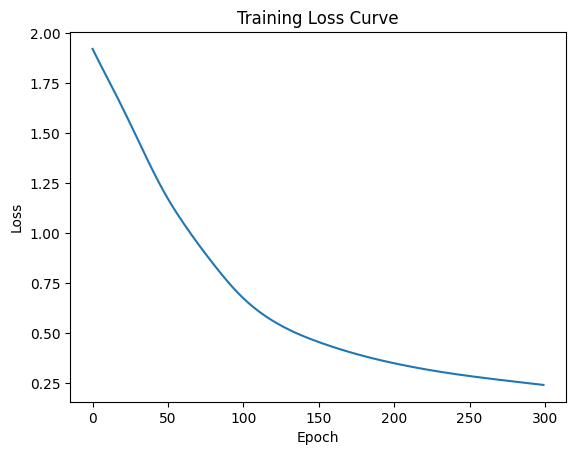

In [12]:
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()

## 🎯 Conclusion

In this notebook we:

- Built an **ANN for classification**
- Used **CrossEntropyLoss**
- Trained the neural network using **Adam optimizer**
- Evaluated the model using **classification accuracy**

Artificial Neural Networks are powerful models capable of learning complex decision boundaries for classification tasks.